In [92]:
from functions import *
import os
import json
import requests

import pandas as pd
import matplotlib.pyplot as plt
import datetime

from pprint import pprint
#from scrapy import Selector
from tqdm.notebook import tqdm

from functions import *

from sqlalchemy import create_engine
import mysql.connector
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer

import plotly.io as pio
pio.renderers = "notebook_connected"


In [32]:
engine = create_engine('sqlite:///../data/states_reddit.db', echo=False, isolation_level="AUTOCOMMIT")

with engine.connect() as conn:
    pass

In [33]:
%load_ext sql
%sql sqlite:///../states_reddit.db --states_data

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [34]:
state_data = pd.read_sql('SELECT * FROM states_data' , engine)
clean_data= {}
for state in subreddits:
    clean_data[state] = clean_text(state_data,state)

In [35]:
models = {}

def modelling (state,text):
    
    vectorizer_model = CountVectorizer(stop_words="english")
    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
    model = BERTopic(

        embedding_model='all-MiniLM-L6-v2',
        low_memory=True,
        ctfidf_model=ctfidf_model,
        vectorizer_model=vectorizer_model,
        representation_model = MaximalMarginalRelevance(diversity=0.2)

    )
    
    topic, prob = model.fit_transform(text)
    models[state] = model


In [36]:
# test runtime around 13mins
for state, data in clean_data.items():
    modelling(state,data)

# data for every state #

In [86]:
#with min_df = 3, get around 22 mins
#with no dmin_df, get around 45 mins
# Create an empty dictionary to store the models and results for each subreddit
grouped_data = state_data.groupby('subreddit').agg({
    'title': list,
    'selftext': list,
    'num_comments': list
})

# Create an empty dictionary to store the models and results for each subreddit
subreddit_models = {}

# Iterate over each subreddit and its corresponding grouped data
for subreddit, data in grouped_data.iterrows():
    # Combine the titles and selftext into a single list
    combined_text = data['title'] + data['selftext']
    
    # Create a BERTopic model instance
    vectorizer_model = CountVectorizer(stop_words="english", min_df=3)
    model = BERTopic(embedding_model='all-MiniLM-L6-v2',low_memory=True)
    
    # Fit the model to the combined text
    topics, probabilities = model.fit_transform(combined_text)
    
    # Store the model and results for the current subreddit
    subreddit_models[subreddit] = {'model': model, 'topics': topics, 'probabilities': probabilities}

subreddit_models

{'Alabama': {'model': <bertopic._bertopic.BERTopic at 0x1d414586610>,
  'topics': [0,
   2,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   2,
   0,
   2,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   2,
   2,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   2,
   0,
   0,
   0,
   2,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
  

In [39]:
# Choose a state (subreddit) manually
chosen_state1 = 'Arkansas' 

# Get the corresponding BERTopic model
model_info = subreddit_models[chosen_state1]



print(f"Topic information for subreddit '{chosen_state1}':")
print(model_info)


Topic information for subreddit 'Arkansas':
{'model': <bertopic._bertopic.BERTopic object at 0x000001D473706810>, 'topics': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

# Sample count for each state #

In [40]:
# Create an empty dictionary to store sample counts for each state
sample_counts = {}

# Iterate over each state and its corresponding cleaned data
for state, data in clean_data.items():
    # Count the number of samples for the current state
    sample_count = len(data)
    
    # Store the sample count for the current state
    sample_counts[state] = sample_count

# Print the sample counts for each state
for state, count in sample_counts.items():
    print(f"State: {state}, Sample Count: {count}")


State: newyork, Sample Count: 656
State: Maine, Sample Count: 711
State: newhampshire, Sample Count: 690
State: vermont, Sample Count: 710
State: massachusetts, Sample Count: 687
State: RhodeIsland, Sample Count: 723
State: Connecticut, Sample Count: 700
State: newjersey, Sample Count: 672
State: Delaware, Sample Count: 692
State: maryland, Sample Count: 623
State: washingtondc, Sample Count: 759
State: WestVirginia, Sample Count: 668
State: Pennsylvania, Sample Count: 616
State: Virginia, Sample Count: 622
State: NorthCarolina, Sample Count: 650
State: southcarolina, Sample Count: 650
State: Georgia, Sample Count: 661
State: florida, Sample Count: 610
State: Alabama, Sample Count: 596
State: Tennessee, Sample Count: 631
State: mississippi, Sample Count: 681
State: Kentucky, Sample Count: 659
State: Ohio, Sample Count: 687
State: Indiana, Sample Count: 684
State: Michigan, Sample Count: 615
State: Louisiana, Sample Count: 670
State: Arkansas, Sample Count: 631
State: missouri, Sample C

# State 1 - Arkansas #

In [41]:
models['Arkansas'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,234,-1_told_ar_walmart_hickey,"[told, ar, walmart, hickey, ozarks, manager, c...",[Many good things came Ozarks Program recently...
1,0,102,0_sanders_huckabee_governor_podium,"[sanders, huckabee, governor, podium, foia, of...",[I sorry outsiders want know cool stuff reason...
2,1,56,1_park_pictures_lake_buffalo,"[park, pictures, lake, buffalo, falls, canyon,...","[Picture I took Lake Conway evening, Picture I..."
3,2,47,2_arrested_police_sheriff_sentenced,"[arrested, police, sheriff, sentenced, officer...",[Arkansas Makes It Illegal For Minors Be Socia...
4,3,33,3_cotton_hutchinson_trump_fox,"[cotton, hutchinson, trump, fox, tom, maga, su...",[Saw FB What guys think tastes guessing notes ...
5,4,32,4_abortion_hemp_ballot_marijuana,"[abortion, hemp, ballot, marijuana, signatures...",[I collecting signatures Arkansas Abortion Ame...
6,5,29,5_wish_hope_coming_arkansas,"[wish, hope, coming, arkansas, stores, 1864, h...",[To all saying Arkansas headed wrong I must We...
7,6,28,6_education_schools_students_teacher,"[education, schools, students, teacher, public...",[By school year fully privatizes public educat...
8,7,23,7_library_county_librarians_books,"[library, county, librarians, books, hector, c...",[Saline County Library Director Fired Refusing...
9,8,22,8_normal_unpack_trick_update,"[normal, unpack, trick, update, fuck, shs, rea...","[So much unpack, So Normal, Normal]"


In [42]:
# pulls a couple of docs aka title or subtexts that represent the chosen topic
models['Arkansas'].get_representative_docs(1)

['Picture I took Lake Conway evening',
 'Picture I took evening Little Rock',
 'photo I took Little Rock evening']

In [96]:
#| label: arkansas-topic-map
# creates a cluster plot of texts and their respective topics/ interactive
arkansas_fig_topics = models['Arkansas'].visualize_topics()
arkansas_fig_topics.show()


In [76]:
arkansas_fig_hierarchy = models['Arkansas'].visualize_hierarchy()
arkansas_fig_hierarchy.show()

In [77]:
# This code generates a bar chart visualization of the top 10 topics for the 'Arkansas' subreddit.
arkansas_fig_barchart = models['Arkansas'].visualize_barchart(top_n_topics=10)
arkansas_fig_barchart.show()

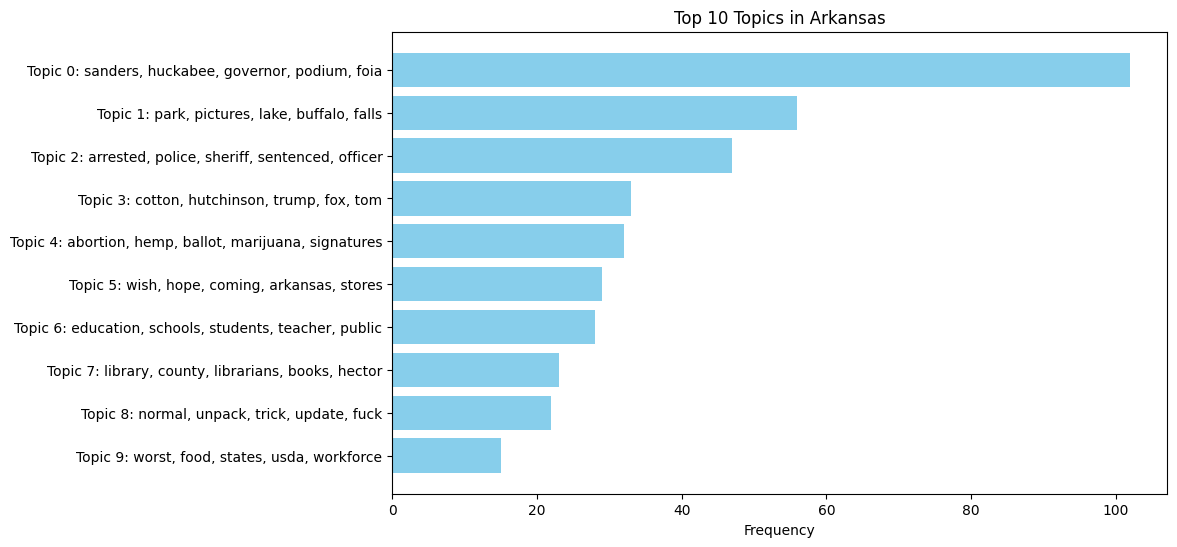

In [83]:
#| label: arkansas-top-topics
import matplotlib.pyplot as plt

arkansas_model = models['Arkansas']
topics_info = arkansas_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in arkansas_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Arkansas')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()


In [79]:
arkansas_fig_heatmap = models['Arkansas'].visualize_heatmap()
arkansas_fig_heatmap.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Assuming you have already fitted BERTopic models for Arkansas and Texas and stored them in the variables 'arkansas_model' and 'texas_model'

# Calculate cosine similarity between topic embeddings of Arkansas and Texas models
similarity_matrix = cosine_similarity(models['Arkansas'].topic_embeddings_, models['texas'].topic_embeddings_)

# Now 'similarity_matrix' contains the cosine similarity scores between each topic embedding of Arkansas and Texas
# You can analyze this matrix to understand the similarity between the topics of the two states


# State 2 - Texas

In [80]:
models['texas'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,195,-1_kids_care_forcing_dogs,"[kids, care, forcing, dogs, vehicle, shows, ta...",[Is anyone genuinely considering moving Texas ...
1,0,60,0_schools_public_teachers_voucher,"[schools, public, teachers, voucher, senate, d...",[Just moved PA middle school aged kid play ins...
2,1,44,1_driving_road_tx_rage,"[driving, road, tx, rage, town, storm, firefli...",[The wildflowers full bloom Central Along HWY ...
3,2,39,2_police_arrest_mccauley_shooting,"[police, arrest, mccauley, shooting, sonic, 91...",[Luke Garrett grinned new mugshot image arraig...
4,3,37,3_ted_cruz_colin_primary,"[ted, cruz, colin, primary, names, vote, beto,...",[Some people Ted office knocked trip currently...
5,4,37,4_spotted_lol_humor_giggling,"[spotted, lol, humor, giggling, beans, rooting...","[quickly bit, embarrassed different reasons, S..."
6,5,36,5_grid_heat_summer_climate,"[grid, heat, summer, climate, energy, temperat...",[Its getting point older adults people risk wo...
7,6,35,6_abortion_kate_pregnancy_ectopic,"[abortion, kate, pregnancy, ectopic, hospital,...",[A woman suing end pregnancy lethal fetal anom...
8,7,31,7_porn_pornhub_pastor_sentenced,"[porn, pornhub, pastor, sentenced, indecency, ...",[Married Texas GOP Who Said Drag Shows Sexuali...
9,8,26,8_abbott_greg_aid_pardon,"[abbott, greg, aid, pardon, supersedes, federa...",[Texas State Rep Glenn Rogers pulls zero parti...


In [ ]:
models['texas'].get_representative_docs(1)

["I live Austin. For years people posted sub asking move here. Every time lot responses complaining weather, cost living, traffic - also lot people talking much love encouraging person come. Today [a young woman posted](https://www.reddit.com/r/Austin/comments/18geuwl/should_a_young_woman_of_reproductive_age_move_to/) saying really wants move Kate Cox story worried - asked opinions. Hundreds responses - every single one I read said don't it. There responses people already moved away, people planning moving away, people want move away, people thinking whether move away. Women worried get unplanned unwanted pregnancy, also women plan get pregnant worry able get life saving procedures something goes wrong pregnancy. And there's change sight - three years there's even chance voting out, unlike states Texas won't let voters put constitutional amendment ballot, done legislature. So much democracy. EDIT: Someone pointed out, important elections - like Texas Supreme Court - next year. EDIT2: Y

In [81]:
# creates a cluster plot of texts and their respective topics/ interactive
texas_fig_topics = models['texas'].visualize_topics()
texas_fig_topics.show()


In [ ]:
texas_fig_hierarchy = models['texas'].visualize_hierarchy()
texas_fig_hierarchy.show()

In [ ]:
texas_fig_barchart = models['texas'].visualize_barchart(top_n_topics=10)
texas_fig_barchart.show()


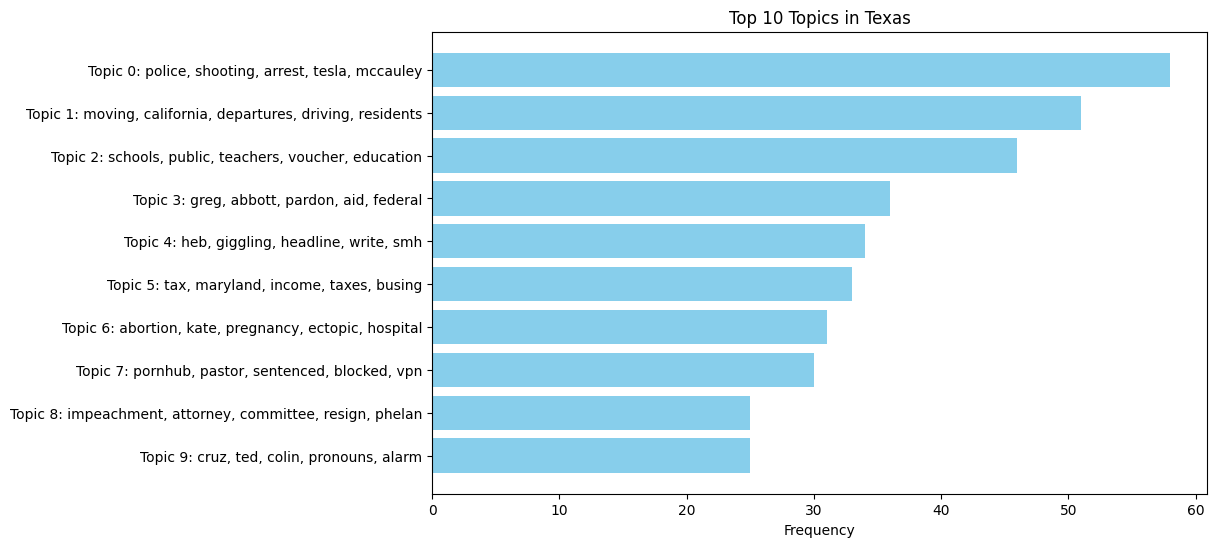

In [ ]:
#| label: texas-top-topics
import matplotlib.pyplot as plt

texas_model = models['texas']
topics_info = texas_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in texas_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Texas')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()


In [ ]:
texas_fig_heatmap = models['texas'].visualize_heatmap()
texas_fig_heatmap.show()

In [ ]:
# i dont actually remember why i did this. it doesnt affect any of the other code but i left it incase it provides something uself idk
df_1 = clean_text(state_data,'texas')

max([len(el.split()) for el in df_1])

404

In [ ]:
print(state_data.head(10))  # Print the first 10 rows


  subreddit                                              title selftext  \
0   newyork  Democrats overtake Monroe County Legislature f...            
1   newyork  New York man who fatally shot woman after her ...            
2   newyork   New Yorkers can now buy booze on Sunday mornings            
3   newyork  Democrats secure a supermajority of seats on B...            
4   newyork  Former Olympian Caitlyn Jenner backs New York ...            
5   newyork  New York Seeks to Limit Social Media’s Grip on...            
6   newyork  Kathy Hochul kicked out of NYPD officer’s wake...            
7   newyork  Governor Hochul declares November as Transgend...            
8   newyork  New York has the second highest membership of ...            
9   newyork  Business lobby attacks as New York nears a non...            

    created_utc       id  upvote_ratio   ups  num_comments  
0  1.699458e+09  17qoenc          0.96  1991            90  
1  1.709309e+09  1b3xn3i          0.99  1761        

In [ ]:
#df = pd.DataFrame(data)

pd.DataFrame(state_data['subreddit'].value_counts())

,count
subreddit,
newyork,500
wyoming,500
Iowa,500
wisconsin,500
minnesota,500
texas,500
oklahoma,500
kansas,500
Nebraska,500


# comparing states #

note = i dont know how to interpret these results, i found the code on the bertopic markdown but just plugged in the database so idk whether its correct

In [95]:
#| label: texas-arkansas-compare
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

# Assuming state_data contains your dataset for all states
# You can use the same sentence model and UMAP configuration
sentence_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# Define a function to fit BERTopic models for a given state
def fit_bertopic_for_state(state_name, state_data):
    state_text = state_data[state_data['subreddit'] == state_name]['title'].tolist() + \
                 state_data[state_data['subreddit'] == state_name]['selftext'].tolist()
    topic_model = BERTopic(embedding_model=sentence_model, umap_model=umap_model)
    topics, probabilities = topic_model.fit_transform(state_text)
    return topic_model

# Assuming pre-fitted BERTopic models for Texas and Arkansas
texas_model = subreddit_models['texas']['model']
arkansas_model = subreddit_models['Arkansas']['model']

# Extract topic embeddings and filter out the generic topic (-1)
texas_embeddings = [texas_model.topic_embeddings_[i] for i in range(len(texas_model.topic_embeddings_)) if i != -1]
arkansas_embeddings = [arkansas_model.topic_embeddings_[i] for i in range(len(arkansas_model.topic_embeddings_)) if i != -1]

# Calculate the cosine similarity matrix between the topic embeddings of Texas and Arkansas
sim_matrix = cosine_similarity(texas_embeddings, arkansas_embeddings)

# Cluster the similarity matrix to group similar topics
linkage_matrix = linkage(sim_matrix, method='ward')
dendro = dendrogram(linkage_matrix, no_plot=True)
ordered_idx = leaves_list(linkage_matrix)

# Reorder the similarity matrix according to the clustering
sim_matrix_ordered = sim_matrix[:, ordered_idx][ordered_idx]

# Get topic names and filter out the generic topic (-1)
arkansas_topic_names = [topic[1] for topic in arkansas_model.get_topic_info().values.tolist() if topic[0] != -1]
texas_topic_names = [topic[1] for topic in texas_model.get_topic_info().values.tolist() if topic[0] != -1]

# Reorder topic names according to the clustering
arkansas_topic_names_ordered = [arkansas_topic_names[i] for i in ordered_idx]
texas_topic_names_ordered = [texas_topic_names[i] for i in ordered_idx]

# Convert the similarity matrix to a DataFrame for better visualization
sim_df = pd.DataFrame(sim_matrix_ordered, index=texas_topic_names_ordered, columns=arkansas_topic_names_ordered)

# Plot the similarity matrix using Plotly for interactivity
fig = px.imshow(sim_df, color_continuous_scale='RdBu_r', origin='lower', labels=dict(x='Arkansas Topics', y='Texas Topics', color='Cosine Similarity'))
fig.update_layout(title='Cosine Similarity Between Texas and Arkansas Topics')
fig.show()

# Find the indices of the maximum value in the similarity matrix
max_sim_idx = np.unravel_index(np.argmax(sim_matrix, axis=None), sim_matrix.shape)

# Get the most similar topics using the reordered indices
most_similar_texas_topic_num = ordered_idx[max_sim_idx[0]]
most_similar_arkansas_topic_num = ordered_idx[max_sim_idx[1]]

# Find the corresponding topic names
most_similar_texas_topic_name = texas_topic_names_ordered[max_sim_idx[0]]
most_similar_arkansas_topic_name = arkansas_topic_names_ordered[max_sim_idx[1]]

# Print the most similar topics and their similarity score
most_similar_score = sim_matrix_ordered[max_sim_idx[0], max_sim_idx[1]]
# Print the most similar topics and their similarity score without rounding up
print(f"Most similar topics:\nTexas Topic: {most_similar_texas_topic_num} ({most_similar_texas_topic_name})\nArkansas Topic: {most_similar_arkansas_topic_num} ({most_similar_arkansas_topic_name})\nCosine Similarity: {most_similar_score:.4f}")


Most similar topics:
Texas Topic: 1 (381)
Arkansas Topic: 1 (372)
Cosine Similarity: 0.9999


### note - this has been rounded up to 1 but is actually 0.999985

Cosine Similarity between Topic 0 of Texas and Topic 0 of Arkansas: 0.66


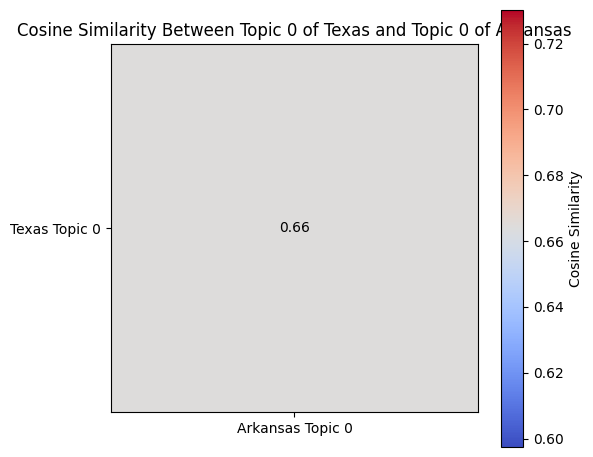

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Assuming your pre-existing BERTopic models are stored in subreddit_models
# subreddit_models[subreddit] = {'model': model, 'topics': topics, 'probabilities': probabilities}

# Load pre-existing BERTopic models for Texas and Arkansas
texas_model = subreddit_models['texas']['model']
arkansas_model = subreddit_models['Arkansas']['model']

# Extract topic embeddings for topic 0
texas_topic_0_embedding = texas_model.topic_embeddings_[0]
arkansas_topic_0_embedding = arkansas_model.topic_embeddings_[0]

# Calculate the cosine similarity between topic 0 from Texas and topic 0 from Arkansas
similarity_score = cosine_similarity([texas_topic_0_embedding], [arkansas_topic_0_embedding])[0, 0]

# Display the similarity score
print(f"Cosine Similarity between Topic 0 of Texas and Topic 0 of Arkansas: {similarity_score:.2f}")

# Plot the similarity score as a heatmap for visual reference
plt.figure(figsize=(6, 5))
plt.imshow([[similarity_score]], cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')
plt.title('Cosine Similarity Between Topic 0 of Texas and Topic 0 of Arkansas')

# Annotate the similarity score on the heatmap
plt.text(0, 0, f"{similarity_score:.2f}", ha='center', va='center', color='black')

# Set ticks and labels
plt.xticks(ticks=[0], labels=['Arkansas Topic 0'])
plt.yticks(ticks=[0], labels=['Texas Topic 0'])

plt.tight_layout()
plt.show()


--------------

# State 3 - FLorida #

In [ ]:
models['florida'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,139,-1_pool_reporting_fired_desantis,"[pool, reporting, fired, desantis, https, nazi...",[[https://www.cbsnews.com/news/climate-action-...
1,0,142,0_live_beach_lived_home,"[live, beach, lived, home, storm, south, life,...",[I lived Palm Beach 4 years never understand p...
2,1,63,1_schools_bible_lgbtq_ban,"[schools, bible, lgbtq, ban, anti, https, arre...",[WTF Florida? The elementary school 3 teachers...
3,2,48,2_ron_desantis_bid_presidential,"[ron, desantis, bid, presidential, rubio, summ...",[DeSantis’ lawyer initially claimed state Flor...
4,3,46,3_motorist_idea_puppy_tree,"[motorist, idea, puppy, tree, turnpike, manner...","[4:45 AM?!? Who fuck thought good idea??, Just..."
5,4,40,4_insurance_premiums_homeowners_property,"[insurance, premiums, homeowners, property, in...","[They ruined Florida. It’s unlivable now, resi..."
6,5,26,5_abortion_ballot_marijuana_amendment,"[abortion, ballot, marijuana, amendment, court...","[Florida Supreme Court allows abortion, mariju..."
7,6,23,6_disney_district_benefits_takeover,"[disney, district, benefits, takeover, creek, ...",[DeSantis' 'War Woke' Backfires As Disney Ends...
8,7,17,7_data_covid_measles_fda,"[data, covid, measles, fda, outbreak, vaccine,...",[‘That decision cost lives’: Covid data case d...
9,8,17,8_hall_indicment_kup_accuses,"[hall, indicment, kup, accuses, seals, blamed,...",[DeSantis lashes Jacksonville man blamed polic...


In [ ]:
models['florida'].get_representative_docs(1)

["WTF Florida? The elementary school 3 teachers short 8 support staff members short. We went PTA meeting went budget school year, unchanged last year, grants State, cut almost 30%. I've printing math, science, social studies lessons internet learning something. She says constant flow subs boring, obviously aren't learning anything class new sub every 3-4 days. We forced look charter schools private schools even though can't afford it. Is goal? Why isn't bigger deal people?",
 'My youngest child starting kindergarten year. We got lucky got teacher brother kindergarten. We absolutely love her! But called yesterday "welcome classroom" speech ask questions youngest son. One questions asking prefers called. He name commonly shortened. Think \'John\' \'Johnathan\' \'\'Ben\' \'Benjamin\'. It literally removes couple letters name that\'s we\'ve always called him. She proceeded inform order child called shortened version actual, birth certificate name, sign waiver fill couple forms won\'t allow

In [ ]:
# creates a cluster plot of texts and their respective topics/ interactive
florida_fig_topics = models['florida'].visualize_topics()
florida_fig_topics.show()


In [ ]:
florida_fig_hierarchy = models['florida'].visualize_hierarchy()
florida_fig_hierarchy.show()

In [ ]:
florida_fig_barchart = models['florida'].visualize_barchart(top_n_topics=10)
florida_fig_barchart.show()

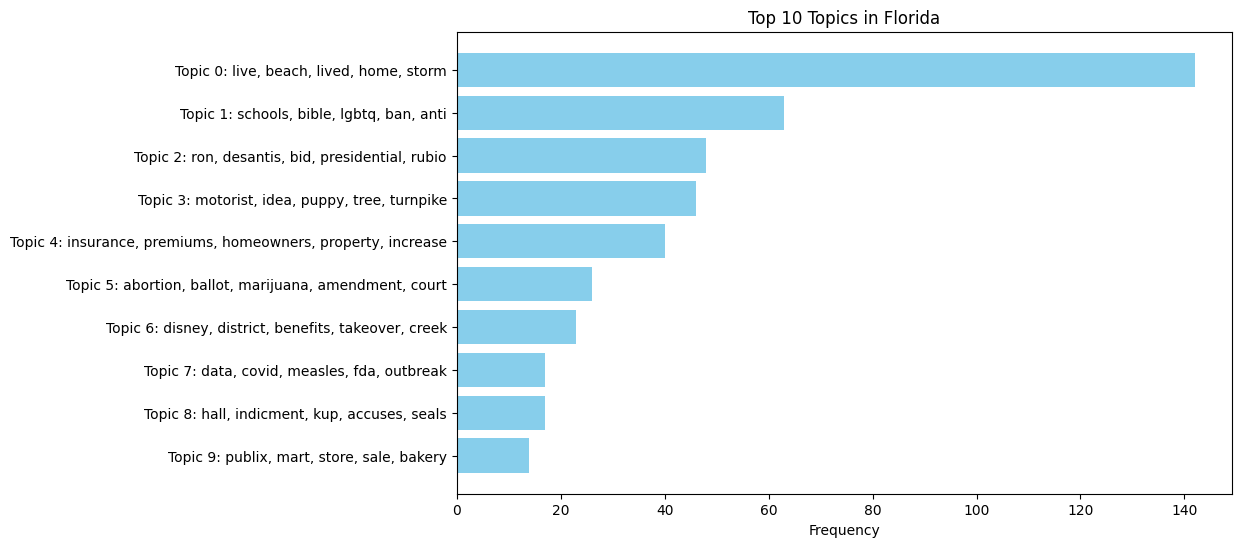

In [ ]:
#| label: florida-top-topics
import matplotlib.pyplot as plt

florida_model = models['florida']
topics_info = florida_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in florida_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Florida')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()

In [ ]:
florida_fig_heatmap = models['florida'].visualize_heatmap()
florida_fig_heatmap.show()

# State 4 - Indiana

In [ ]:
models['Indiana'].get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,191,-1_gary_todd_state_carbon,"[gary, todd, state, carbon, environment, wetla...","[So, Todd Young's office inside building DR. I..."
1,0,202,0_daylight_park_dst_indianapolis,"[daylight, park, dst, indianapolis, indiana, s...",[Maybe putting universe help…(!) I met guy las...
2,1,57,1_marijuana_legalization_lawmakers_legalize,"[marijuana, legalization, lawmakers, legalize,...",[Does anyone living Indiana think weed legal? ...
3,2,56,2_scored_son_love_reposts,"[scored, son, love, reposts, stats, misery, me...","[Just dropping get company misery, I guess., M..."
4,3,30,3_braun_mike_election_images,"[braun, mike, election, images, trump, gop, jo...",[I've Democrat whole life first election I'm v...
5,4,29,4_arrested_officer_charges_pornography,"[arrested, officer, charges, pornography, otte...",[&gt; Indiana Republican Joshua Craft arrested...
6,5,22,5_senate_wage_news_guard,"[senate, wage, news, guard, minimum, texas, sp...",[https://www.wthr.com/article/news/local/india...
7,6,21,6_books_schools_religious_chaplains,"[books, schools, religious, chaplains, banned,...","[Today, I received letter daughter's school. P..."
8,7,21,7_gender_transgender_minors_court,"[gender, transgender, minors, court, dysphoria...","[The parents, self-described devout Christians..."
9,8,19,8_abortion_violence_org_bans,"[abortion, violence, org, bans, idahocapitalsu...",[The [Hoosier Abortion Fund](https://alloption...


In [ ]:
models['Indiana'].get_representative_docs(1)

["Does anyone living Indiana think weed legal? I walk old people smell like daily, pass cars smell strong I smell windows up. And yet all articles say there's hope here. I personally don't I see harm letting others it. It's better cancer cigaretts drunk kidney failure. While ofc consuming anything pure clean air harmful different organs, healthier ways consume weed alcohol nicotine. I want know fellow Hoosiers all ages backgrounds think. IMO I think all states many people older generations closed mindsets much say things mainly impact younger generations. I know lot younger folks enjoy it. And you're going cry addiction don't forget anything addicting. Fast food, nicotine, alcohol addictive substances consumed us Hoosiers. Anything giving brain ability make happy chemical addictive.",
 "Midwest Hemp Council 2023 Indiana Legislative Summary The Indiana Legislative session 2023 concluded early morning hours Friday, April 28 almost four months work. Throughout session, Midwest Hemp Counci

In [ ]:
indiana_fig_topics = models['Indiana'].visualize_topics()
indiana_fig_topics.show()

In [ ]:
indiana_fig_hierarchy = models['Indiana'].visualize_hierarchy()
indiana_fig_hierarchy.show()

In [ ]:
indiana_fig_barchart = models['Indiana'].visualize_barchart(top_n_topics=10)
indiana_fig_barchart.show()

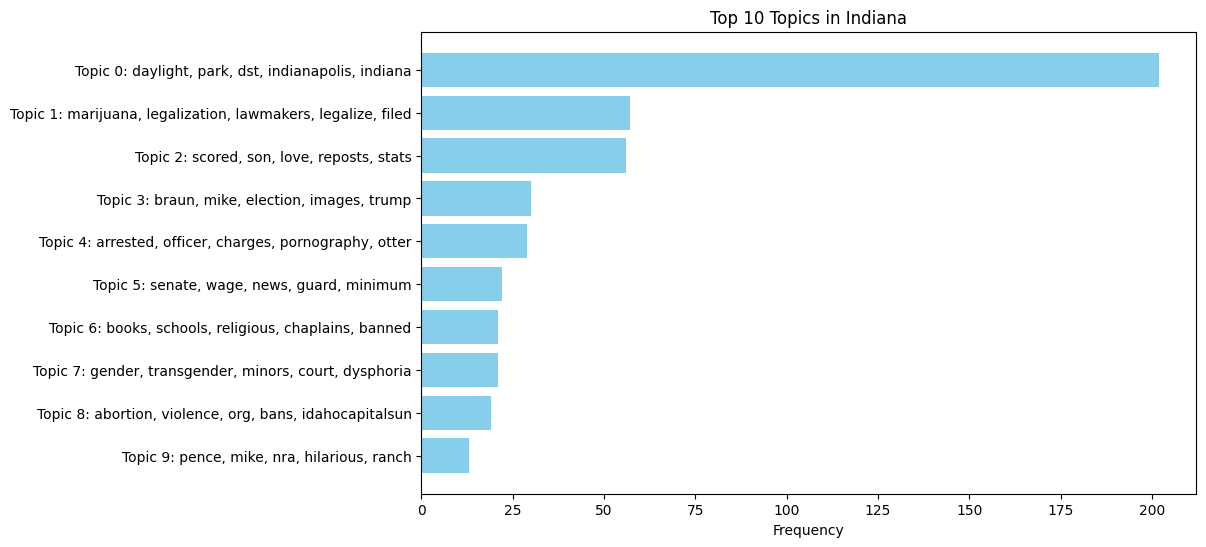

In [ ]:
#| label: indiana-top-topics
import matplotlib.pyplot as plt

indiana_model = models['Indiana']
topics_info = indiana_model.get_topic_info()
top_n_topics = 10

# Assign names to the columns for clarity
topics_info.columns = ['Topic', 'Count', 'Name', 'Representation', 'Representative Docs']

# Filter out the -1 topic which represents outliers/noise
topics_info = topics_info[topics_info.Topic != -1]

# Select the top N topics
top_topics = topics_info.head(top_n_topics)

# Extract the topic numbers and their frequencies
topic_nums = top_topics.Topic.values
topic_freqs = top_topics.Count.values

# Get the top words for each topic
top_words = [', '.join([word for word, _ in indiana_model.get_topic(topic_num)[:5]]) for topic_num in topic_nums]

# Plot the barchart
plt.figure(figsize=(10, 6))
plt.barh(range(len(topic_nums)), topic_freqs, color='skyblue')
plt.yticks(range(len(topic_nums)), [f'Topic {num}: {words}' for num, words in zip(topic_nums, top_words)])
plt.xlabel('Frequency')
plt.title('Top 10 Topics in Indiana')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest frequency at the top
plt.show()

In [ ]:
indiana_fig_heatmap = models['Indiana'].visualize_heatmap()
indiana_fig_heatmap.show()

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import pandas as pd
import numpy as np

# Assuming pre-fitted BERTopic models for Florida and Indiana
florida_model = subreddit_models['florida']['model']
indiana_model = subreddit_models['Indiana']['model']

# Extract topic embeddings and filter out the generic topic (-1)
florida_embeddings = np.array([florida_model.topic_embeddings_[i] for i in range(len(florida_model.topic_embeddings_)) if i != -1])
indiana_embeddings = np.array([indiana_model.topic_embeddings_[i] for i in range(len(indiana_model.topic_embeddings_)) if i != -1])

# Verify embeddings are not identical and have correct dimensions
print("Florida Embeddings Shape:", florida_embeddings.shape)
print("Indiana Embeddings Shape:", indiana_embeddings.shape)

# Manually verify a few cosine similarities to ensure correctness
manual_sim = cosine_similarity([florida_embeddings[0]], [indiana_embeddings[0]])
print("Manual Cosine Similarity Check:", manual_sim)

# Calculate the cosine similarity matrix between the topic embeddings of Florida and Indiana
sim_matrix = cosine_similarity(florida_embeddings, indiana_embeddings)

# Convert the similarity matrix to a DataFrame for better visualization
florida_topic_info = pd.DataFrame(florida_model.get_topic_info())
indiana_topic_info = pd.DataFrame(indiana_model.get_topic_info())

# Filter out the generic topic (-1) and get topic names
florida_topic_names = florida_topic_info[florida_topic_info['Topic'] != -1]['Name'].tolist()
indiana_topic_names = indiana_topic_info[indiana_topic_info['Topic'] != -1]['Name'].tolist()

# Create a DataFrame for the similarity matrix
sim_df = pd.DataFrame(sim_matrix, index=florida_topic_names, columns=indiana_topic_names)

# Plot the similarity matrix using Plotly for interactivity
fig = px.imshow(sim_df, color_continuous_scale='RdBu_r', origin='lower', labels=dict(x='Indiana Topics', y='Florida Topics', color='Cosine Similarity'))
fig.update_layout(title='Cosine Similarity Between Florida and Indiana Topics')
fig.show()

# Find the indices of the maximum value in the similarity matrix
max_sim_idx = np.unravel_index(np.argmax(sim_matrix, axis=None), sim_matrix.shape)

# Get the most similar topics using the original indices
most_similar_florida_topic_num = max_sim_idx[0]
most_similar_indiana_topic_num = max_sim_idx[1]

# Find the corresponding topic names
most_similar_florida_topic_name = florida_topic_names[most_similar_florida_topic_num]
most_similar_indiana_topic_name = indiana_topic_names[most_similar_indiana_topic_num]

# Print the most similar topics and their similarity score without rounding up
most_similar_score = sim_matrix[most_similar_florida_topic_num, most_similar_indiana_topic_num]
print(f"Most similar topics:\nFlorida Topic: {most_similar_florida_topic_num} ({most_similar_florida_topic_name})\nIndiana Topic: {most_similar_indiana_topic_num} ({most_similar_indiana_topic_name})\nCosine Similarity: {most_similar_score:.6f}")


NameError: name 'subreddit_models' is not defined

# cross analysing all states

In [ ]:
# Define buzzwords 
buzzwords = ['abortion', 'democrat' 'republican', 'cops', 'marijuana', 'senate','president','shooting','gun','senate', 'war', 'election', 'Biden', 'Trump', 'cannabis', 'immigration']

# Function to parse top topics for buzzwords and return states where they occur
# Function to parse top topics for buzzwords and return states where they occur
def parse_topics_for_buzzwords_with_states(subreddit_models):
    buzzword_states = {buzzword: [] for buzzword in buzzwords}
    for state, model_data in subreddit_models.items():
        model = model_data['model']
        topics = model.get_topic_info()
        for index, topic in topics.iterrows():
            topic_name = topic['Name'].lower()  # Convert topic name to lowercase
            for buzzword in buzzwords:
                if buzzword.lower() in topic_name:  # Check if buzzword is a substring of topic name
                    buzzword_states[buzzword].append(state)
    return buzzword_states



# Get buzzword states for all states and topics
buzzword_states = parse_topics_for_buzzwords_with_states(subreddit_models)

# Count buzzword occurrences across states
common_buzzword_states = {}
for buzzword, states in buzzword_states.items():
    common_buzzword_states[buzzword] = (len(states), states)

# Sort common buzzwords based on counts
sorted_buzzwords = sorted(common_buzzword_states.items(), key=lambda x: x[1][0], reverse=True)

# Get the top 5 common buzzwords
top_common_buzzwords = sorted_buzzwords[:5]

# Print buzzword counts and states
print("Buzzword Counts and States:")
for buzzword, (count, states) in common_buzzword_states.items():
    print(f"{buzzword}: {count} (Seen in: {', '.join(states)})")

# Print top 5 common buzzwords
print("Top 5 Common Sociopolitical Buzzwords Across States:")
for buzzword, (count, states) in top_common_buzzwords:
    print(f"{buzzword}: {count} (Seen in: {', '.join(states)})")


# trending topics in each state

In [ ]:
from tabulate import tabulate

# Group by subreddit and find the row with the maximum ups in each group
most_popular_posts = state_data.loc[state_data.groupby('subreddit')['ups'].idxmax()]

# Display the most popular post in each state
table = most_popular_posts[['subreddit', 'title', 'ups']]
table.columns = ['State', 'Title', 'Upvotes']
print(tabulate(table, headers='keys', tablefmt='grid'))

# created database for interactive map

In [ ]:
# Create and connect to the first SQLite database
conn1 = sqlite3.connect('state_subreddit_data.db')
cur1 = conn1.cursor()

# Create the database table for subreddit data
cur1.execute('''
    CREATE TABLE IF NOT EXISTS subreddit_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        subreddit TEXT NOT NULL,
        title TEXT NOT NULL,
        upvote_ratio REAL NOT NULL,
        upvotes INTEGER NOT NULL,
        num_comments INTEGER NOT NULL
    )
''')

# Insert data into the database
for index, row in state_data.iterrows():
    cur1.execute('''
        INSERT INTO subreddit_data (subreddit, title, upvote_ratio, upvotes, num_comments)
        VALUES (?, ?, ?, ?, ?)
    ''', (row['subreddit'], row['title'], row['upvote_ratio'], row['ups'], row['num_comments']))

# Commit the changes and close the connection
conn1.commit()
conn1.close()

print("Subreddit data inserted successfully.")

# Function to get the top 3 topics for a state
def get_top_topics(model):
    topics = model.get_topic_info().head(3)
    return topics['Name'].tolist()

# Create and connect to the second SQLite database
conn2 = sqlite3.connect('state_topics_data.db')
cur2 = conn2.cursor()

# Create the database table for state topics data
cur2.execute('''
    CREATE TABLE IF NOT EXISTS state_topics (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        state TEXT NOT NULL,
        topic1 TEXT,
        topic2 TEXT,
        topic3 TEXT
    )
''')

# Insert data into the database
for state, model in models.items():
    top_topics = get_top_topics(model)
    topic1, topic2, topic3 = top_topics if len(top_topics) == 3 else (top_topics + [None] * (3 - len(top_topics)))
    cur2.execute('''
        INSERT INTO state_topics (state, topic1, topic2, topic3)
        VALUES (?, ?, ?, ?)
    ''', (state, topic1, topic2, topic3))

# Commit the changes and close the connection
conn2.commit()
conn2.close()

print("State topics data inserted successfully.")

# Reconnect to the databases
conn1 = sqlite3.connect('state_subreddit_data.db')
cur1 = conn1.cursor()

conn2 = sqlite3.connect('state_topics_data.db')
cur2 = conn2.cursor()

# Create and connect to the final merged database
conn_final = sqlite3.connect('merged_state_data.db')
cur_final = conn_final.cursor()

# Create the database table for the merged data
cur_final.execute('''
    CREATE TABLE IF NOT EXISTS merged_state_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        state TEXT NOT NULL,
        top_subreddit TEXT NOT NULL,
        title TEXT NOT NULL,
        upvote_ratio REAL NOT NULL,
        upvotes INTEGER NOT NULL,
        num_comments INTEGER NOT NULL,
        topic1 TEXT,
        topic2 TEXT,
        topic3 TEXT
    )
''')

# Merge data from the two databases
cur1.execute('SELECT * FROM subreddit_data')
subreddit_data = cur1.fetchall()

for row in subreddit_data:
    subreddit = row[1]
    title = row[2]
    upvote_ratio = row[3]
    upvotes = row[4]
    num_comments = row[5]

    cur2.execute('SELECT * FROM state_topics WHERE state = ?', (subreddit,))
    topics = cur2.fetchone()
    if topics:
        state = topics[1]
        topic1 = topics[2]
        topic2 = topics[3]
        topic3 = topics[4]
    else:
        state = subreddit
        topic1 = None
        topic2 = None
        topic3 = None

    cur_final.execute('''
        INSERT INTO merged_state_data (state, top_subreddit, title, upvote_ratio, upvotes, num_comments, topic1, topic2, topic3)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (state, subreddit, title, upvote_ratio, upvotes, num_comments, topic1, topic2, topic3))

# Commit the changes and close the connections
conn_final.commit()
conn_final.close()
conn1.close()
conn2.close()

print("Data merged successfully.")


# Connect to the merged database
conn = sqlite3.connect('merged_state_data.db')
cur = conn.cursor()

# Query the merged data
cur.execute('SELECT * FROM merged_state_data')
rows = cur.fetchall()

# Get the column names
column_names = [description[0] for description in cur.description]

# Load data into a DataFrame for better formatting
merged_data = pd.DataFrame(rows, columns=column_names)


# Close the connection
conn.close()

# Select the top post for each state by the number of upvotes
top_posts = merged_data.loc[merged_data.groupby('state')['upvotes'].idxmax()]


# Drop the 'top_subreddit' column
top_posts = top_posts.drop(columns=['top_subreddit'])
top_posts = top_posts.rename(columns={'title': 'name of top subreddit'})
# Filter out unnecessary rows
top_posts = top_posts[top_posts['state'] != 'politics']
top_posts = top_posts[top_posts['state'] != 'democrats']
top_posts = top_posts[top_posts['state'] != 'republicans']
# Print the final DataFrame
print(top_posts)

# Save the DataFrame to a CSV file

# Convert top_posts to a DataFrame (if it's not already one)
top_posts_df = pd.DataFrame(top_posts)

# Save the DataFrame to a CSV file
top_posts_df.to_csv('top_posts.csv', index=False)

print("Top posts saved as 'top_posts.csv'")

